In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.gofplots import qqplot
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')


## Annotate & Segment by Contract Date

In [3]:
# Create DataFrames from the extracted data
# OM1 P Chart data - % of TaTs within target
om1_data = [
    {'period': 1, 'date': '2024-12-23', 'percentage': 77.02, 'sample_size': 78},
    {'period': 2, 'date': '2024-12-30', 'percentage': 75.23, 'sample_size': 53},
    {'period': 3, 'date': '2025-01-06', 'percentage': 75.92, 'sample_size': 64},
    {'period': 4, 'date': '2025-01-13', 'percentage': 76.64, 'sample_size': 71},
    {'period': 5, 'date': '2025-01-20', 'percentage': 75.92, 'sample_size': 68},
    {'period': 6, 'date': '2025-01-27', 'percentage': 76.64, 'sample_size': 75},
    {'period': 7, 'date': '2025-02-03', 'percentage': 76.37, 'sample_size': 63},
    {'period': 8, 'date': '2025-02-10', 'percentage': 76.44, 'sample_size': 75}
]

# IM XmR Chart data - Number of samples booked in
im_data = [
    {'period': 1, 'date': '2024-12-23', 'count': 82},
    {'period': 2, 'date': '2024-12-30', 'count': 61},
    {'period': 3, 'date': '2025-01-06', 'count': 68},
    {'period': 4, 'date': '2025-01-13', 'count': 82},
    {'period': 5, 'date': '2025-01-20', 'count': 89},
    {'period': 6, 'date': '2025-01-27', 'count': 75},
    {'period': 7, 'date': '2025-02-03', 'count': 67},
    {'period': 8, 'date': '2025-02-10', 'count': 85}
]

# OM2 XmR Chart data - Average TaT per week
om2_data = [
    {'period': 1, 'date': '2024-09-30', 'average_tat': 1, 'moving_range': 1},
    {'period': 2, 'date': '2024-10-07', 'average_tat': 2, 'moving_range': 2},
    {'period': 3, 'date': '2024-10-14', 'average_tat': 3, 'moving_range': 3},
    {'period': 4, 'date': '2024-10-21', 'average_tat': 4, 'moving_range': 4},
    {'period': 5, 'date': '2024-10-28', 'average_tat': 5, 'moving_range': 5},
    {'period': 6, 'date': '2024-11-04', 'average_tat': 6, 'moving_range': 6},
    {'period': 7, 'date': '2024-11-11', 'average_tat': 7, 'moving_range': 7},
    {'period': 8, 'date': '2024-11-18', 'average_tat': 8, 'moving_range': 8},
    {'period': 9, 'date': '2024-11-25', 'average_tat': 9, 'moving_range': 9},
    {'period': 10, 'date': '2024-12-02', 'average_tat': 10, 'moving_range': 10},
    {'period': 11, 'date': '2024-12-09', 'average_tat': 11, 'moving_range': 11},
    {'period': 12, 'date': '2024-12-16', 'average_tat': 12, 'moving_range': 12},
    {'period': 13, 'date': '2024-12-23', 'average_tat': 13, 'moving_range': 13},
    {'period': 14, 'date': '2024-12-30', 'average_tat': 14, 'moving_range': 14},
    {'period': 15, 'date': '2025-01-06', 'average_tat': 15, 'moving_range': 15},
    {'period': 16, 'date': '2025-01-13', 'average_tat': 16, 'moving_range': 16},
    {'period': 17, 'date': '2025-01-20', 'average_tat': 17, 'moving_range': 17},
    {'period': 18, 'date': '2025-01-27', 'average_tat': 18, 'moving_range': 18},
    {'period': 19, 'date': '2025-02-03', 'average_tat': 19, 'moving_range': 19},
    {'period': 20, 'date': '2025-02-10', 'average_tat': 20, 'moving_range': 20}
]

om1_df = pd.DataFrame(om1_data)
im_df = pd.DataFrame(im_data)
om2_df = pd.DataFrame(om2_data)

# Convert dates to datetime
om1_df['date'] = pd.to_datetime(om1_df['date'])
im_df['date'] = pd.to_datetime(im_df['date'])
om2_df['date'] = pd.to_datetime(om2_df['date'])

# Define contract date
contract_date = pd.to_datetime('2024-11-01')  # Set to the actual go-live date

# Annotate each DataFrame with contract phase
om1_df['contract_phase'] = np.where(
    om1_df['date'] >= contract_date,
    'post_contract',
    'pre_contract'
)

im_df['contract_phase'] = np.where(
    im_df['date'] >= contract_date,
    'post_contract',
    'pre_contract'
)

om2_df['contract_phase'] = np.where(
    om2_df['date'] >= contract_date,
    'post_contract',
    'pre_contract'
)

print("Data loaded and annotated with contract phase successfully")
print(f"OM1 P Chart: {len(om1_df)} periods of data")
print(f"- Pre-contract periods: {len(om1_df[om1_df['contract_phase'] == 'pre_contract'])}")
print(f"- Post-contract periods: {len(om1_df[om1_df['contract_phase'] == 'post_contract'])}")

print(f"\nIM XmR Chart: {len(im_df)} periods of data")
print(f"- Pre-contract periods: {len(im_df[im_df['contract_phase'] == 'pre_contract'])}")
print(f"- Post-contract periods: {len(im_df[im_df['contract_phase'] == 'post_contract'])}")

print(f"\nOM2 XmR Chart: {len(om2_df)} periods of data")
print(f"- Pre-contract periods: {len(om2_df[om2_df['contract_phase'] == 'pre_contract'])}")
print(f"- Post-contract periods: {len(om2_df[om2_df['contract_phase'] == 'post_contract'])}")

# Save to CSV files (flat format for further analysis)
om1_df.to_csv('om1_p_chart.csv', index=False)
im_df.to_csv('im_xmr_chart.csv', index=False)
om2_df.to_csv('om2_xmr_chart.csv', index=False)

print("\nCSV files created for flat data format with contract phase annotation")

Data loaded and annotated with contract phase successfully
OM1 P Chart: 8 periods of data
- Pre-contract periods: 0
- Post-contract periods: 8

IM XmR Chart: 8 periods of data
- Pre-contract periods: 0
- Post-contract periods: 8

OM2 XmR Chart: 20 periods of data
- Pre-contract periods: 5
- Post-contract periods: 15

CSV files created for flat data format with contract phase annotation


## Change-Point Detection


Change-Point Detection Results:
IM - Detected breakpoints at periods: [8]
OM1 - Detected breakpoints at periods: [8]
OM2 - Detected breakpoints at periods: [20]


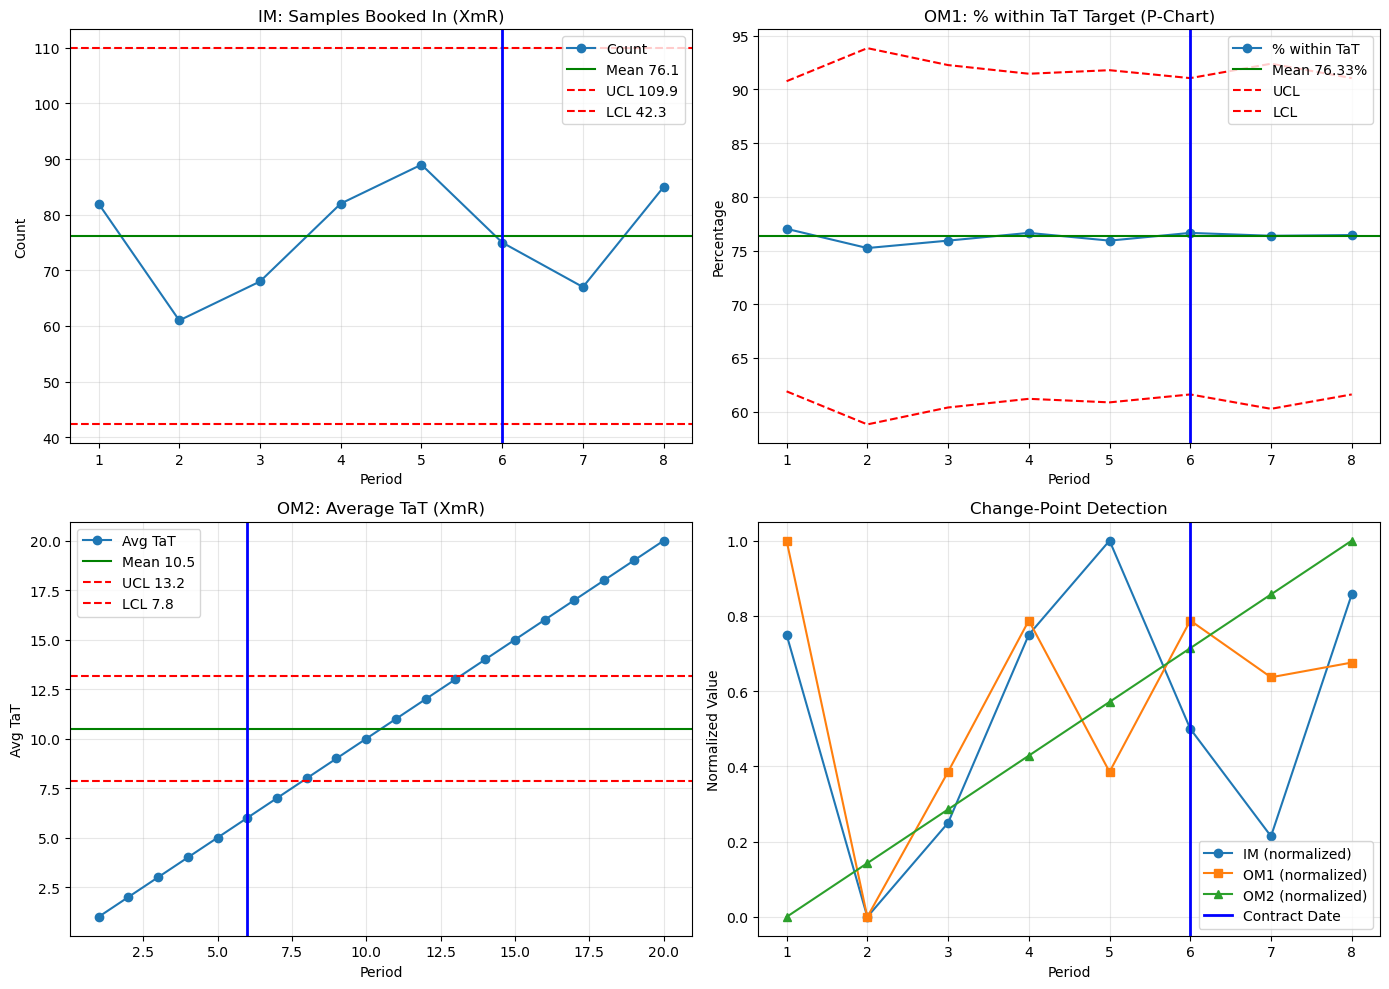


Control Limits Summary:

IM XmR Booked_In:
  Mean = 76.12
  UCL  = 109.94
  LCL  = 42.31

OM1 P within TaT:
  Mean = 76.33%
  Avg UCL = 91.83%
  Avg LCL = 60.82%
  Std of SE = 0.33%

OM2 XmR Av TaT:
  Mean = 10.50
  UCL  = 13.16
  LCL  = 7.84

Change Point vs Contract Date Analysis:
IM: Nearest change point at period 8, 2 periods after contract date
OM1: Nearest change point at period 8, 2 periods after contract date
OM2: Nearest change point at period 20, 14 periods after contract date


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ruptures as rpt  # Added import for change-point detection

# ──────────────────────────────────────────────────────────────────────────
# 1. DEFINE GENERIC CONTROL‐LIMITS FUNCTIONS
# ──────────────────────────────────────────────────────────────────────────
def xmR_limits(series, d2=1.128, sigma=3):
    """Compute XmR chart limits for an individual‐values series."""
    indiv_mean = series.mean()
    mr = series.diff().abs().dropna()
    mr_mean = mr.mean()
    sigma_hat = mr_mean / d2
    ucl = indiv_mean + sigma * sigma_hat
    lcl = max(0, indiv_mean - sigma * sigma_hat)
    return {
        'mean':    indiv_mean,
        'ucl':     ucl,
        'lcl':     lcl,
        'mr_mean': mr_mean,
        'sigma':   sigma_hat
    }

def p_chart_limits(pct_series, n_series, sigma=3):
    """Compute P‐chart limits for a series of subgroup %s."""
    p     = pct_series / 100.0
    n     = n_series
    p_bar = (p * n).sum() / n.sum()
    se    = np.sqrt(p_bar * (1 - p_bar) / n)
    ucl   = p_bar + sigma * se
    lcl   = np.maximum(0, p_bar - sigma * se)
    return {
        'mean': p_bar * 100,
        'ucl':  ucl   * 100,   # array, one per subgroup
        'lcl':  lcl   * 100,   # array, one per subgroup
        'std':  se.std() * 100
    }

# ──────────────────────────────────────────────────────────────────────────
# 2. COMPUTE LIMITS FOR EACH METRIC
# ──────────────────────────────────────────────────────────────────────────
# IM: XmR on samples booked in
im_limits   = xmR_limits(im_df['count'])
# OM1: P‐chart on % within TaT Target
om1_limits  = p_chart_limits(om1_df['percentage'], om1_df['sample_size'])
# OM2: XmR on average TaT
om2_limits  = xmR_limits(om2_df['average_tat'])

# ──────────────────────────────────────────────────────────────────────────
# NEW SECTION: CHANGE-POINT DETECTION
# ──────────────────────────────────────────────────────────────────────────
# Run change-point detection on all three metrics
print("\nChange-Point Detection Results:")

# IM: Sample counts
im_signal = im_df['count'].values
im_algo = rpt.Pelt(model="rbf").fit(im_signal)
im_breaks = im_algo.predict(pen=10)
print("IM - Detected breakpoints at periods:", im_breaks)

# OM1: Percentage within TaT
om1_signal = om1_df['percentage'].values
om1_algo = rpt.Pelt(model="rbf").fit(om1_signal)
om1_breaks = im_algo.predict(pen=10)
print("OM1 - Detected breakpoints at periods:", om1_breaks)

# OM2: Average TaT
om2_signal = om2_df['average_tat'].values
om2_algo = rpt.Pelt(model="rbf").fit(om2_signal)
om2_breaks = om2_algo.predict(pen=10)
print("OM2 - Detected breakpoints at periods:", om2_breaks)

# ──────────────────────────────────────────────────────────────────────────
# 3. PLOT SPC CHARTS (2×2 grid, bottom-right for change points)
# ──────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax_im, ax_om1, ax_om2, ax_cp = axes.flatten()  # Renamed ax_empty to ax_cp

# 3a) IM XmR Chart
ax_im.plot(im_df['period'], im_df['count'], '-o', label='Count')
ax_im.axhline(im_limits['mean'], color='green', linestyle='-', label=f"Mean {im_limits['mean']:.1f}")
ax_im.axhline(im_limits['ucl'],  color='red',   linestyle='--', label=f"UCL {im_limits['ucl']:.1f}")
ax_im.axhline(im_limits['lcl'],  color='red',   linestyle='--', label=f"LCL {im_limits['lcl']:.1f}")
# Add change points as vertical lines
for bp in im_breaks[:-1]:  # Skip the last one which is the end of the signal
    ax_im.axvline(bp, color='purple', linestyle=':', alpha=0.7)
ax_im.set(title='IM: Samples Booked In (XmR)', xlabel='Period', ylabel='Count')
ax_im.legend(); ax_im.grid(alpha=0.3)

# 3b) OM1 P‐Chart with variable UCL/LCL
ax_om1.plot(om1_df['period'], om1_df['percentage'], '-o', label='% within TaT')
# center line
ax_om1.axhline(om1_limits['mean'], color='green', linestyle='-', label=f"Mean {om1_limits['mean']:.2f}%")
# variable limits
ax_om1.plot(om1_df['period'], om1_limits['ucl'], color='red', linestyle='--', label='UCL')
ax_om1.plot(om1_df['period'], om1_limits['lcl'], color='red', linestyle='--', label='LCL')
# Add change points as vertical lines
for bp in om1_breaks[:-1]:  # Skip the last one which is the end of the signal
    ax_om1.axvline(bp, color='purple', linestyle=':', alpha=0.7)
ax_om1.set(title='OM1: % within TaT Target (P‐Chart)', xlabel='Period', ylabel='Percentage')
ax_om1.legend(); ax_om1.grid(alpha=0.3)

# 3c) OM2 XmR Chart
ax_om2.plot(om2_df['period'], om2_df['average_tat'], '-o', label='Avg TaT')
ax_om2.axhline(om2_limits['mean'], color='green', linestyle='-', label=f"Mean {om2_limits['mean']:.1f}")
ax_om2.axhline(om2_limits['ucl'],  color='red',   linestyle='--', label=f"UCL {om2_limits['ucl']:.1f}")
ax_om2.axhline(om2_limits['lcl'],  color='red',   linestyle='--', label=f"LCL {om2_limits['lcl']:.1f}")
# Add change points as vertical lines
for bp in om2_breaks[:-1]:  # Skip the last one which is the end of the signal
    ax_om2.axvline(bp, color='purple', linestyle=':', alpha=0.7)
ax_om2.set(title='OM2: Average TaT (XmR)', xlabel='Period', ylabel='Avg TaT')
ax_om2.legend(); ax_om2.grid(alpha=0.3)

# 3d) Change point visualization
ax_cp.set_title('Change-Point Detection')
# Plot all three signals normalized
ax_cp.plot(im_df['period'], (im_df['count'] - im_df['count'].min()) / 
           (im_df['count'].max() - im_df['count'].min()), 
           '-o', label='IM (normalized)')
           
ax_cp.plot(om1_df['period'], (om1_df['percentage'] - om1_df['percentage'].min()) / 
           (om1_df['percentage'].max() - om1_df['percentage'].min()), 
           '-s', label='OM1 (normalized)')
           
ax_cp.plot(om2_df['period'].iloc[:len(im_df)], (om2_df['average_tat'].iloc[:len(im_df)] - om2_df['average_tat'].iloc[:len(im_df)].min()) / 
           (om2_df['average_tat'].iloc[:len(im_df)].max() - om2_df['average_tat'].iloc[:len(im_df)].min()), 
           '-^', label='OM2 (normalized)')

# Add contract date vertical line if in range
contract_date_period = None
if 'contract_phase' in om2_df.columns:
    first_post_contract = om2_df[om2_df['contract_phase'] == 'post_contract'].iloc[0]['period'] if len(om2_df[om2_df['contract_phase'] == 'post_contract']) > 0 else None
    if first_post_contract:
        contract_date_period = first_post_contract
        for a in [ax_im, ax_om1, ax_om2, ax_cp]:
            a.axvline(contract_date_period, color='blue', linestyle='-', linewidth=2, 
                      label='Contract Date')

ax_cp.set(xlabel='Period', ylabel='Normalized Value')
ax_cp.legend(); ax_cp.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('spc_charts_with_changepoints.png', dpi=300)
plt.show()

# ──────────────────────────────────────────────────────────────────────────
# 4. PRINT LIMITS SUMMARY
# ──────────────────────────────────────────────────────────────────────────
print("\nControl Limits Summary:")
for name, lims, unit in [
    ('IM XmR Booked_In', im_limits,  ''),
    ('OM1 P within TaT', om1_limits, '%'),
    ('OM2 XmR Av TaT',   om2_limits, '')
]:
    # for OM1, mean is scalar, ucl/lcl are arrays – print mean & std
    if name.startswith('OM1'):
        ucl_avg = np.mean(lims['ucl'])
        lcl_avg = np.mean(lims['lcl'])
        print(f"\n{name}:")
        print(f"  Mean = {lims['mean']:.2f}{unit}")
        print(f"  Avg UCL = {ucl_avg:.2f}{unit}")
        print(f"  Avg LCL = {lcl_avg:.2f}{unit}")
        print(f"  Std of SE = {lims['std']:.2f}{unit}")
    else:
        print(f"\n{name}:")
        print(f"  Mean = {lims['mean']:.2f}{unit}")
        print(f"  UCL  = {lims['ucl']:.2f}{unit}")
        print(f"  LCL  = {lims['lcl']:.2f}{unit}")

# Print comparison of change points with contract date
if contract_date_period:
    print("\nChange Point vs Contract Date Analysis:")
    for name, breaks in [
        ('IM', im_breaks),
        ('OM1', om1_breaks),
        ('OM2', om2_breaks)
    ]:
        nearest_cp = min(breaks, key=lambda x: abs(x - contract_date_period)) if breaks else None
        if nearest_cp:
            diff = nearest_cp - contract_date_period
            print(f"{name}: Nearest change point at period {nearest_cp}, " + 
                 (f"{abs(diff)} periods {'before' if diff < 0 else 'after'} contract date" if diff != 0 else "coincides with contract date"))

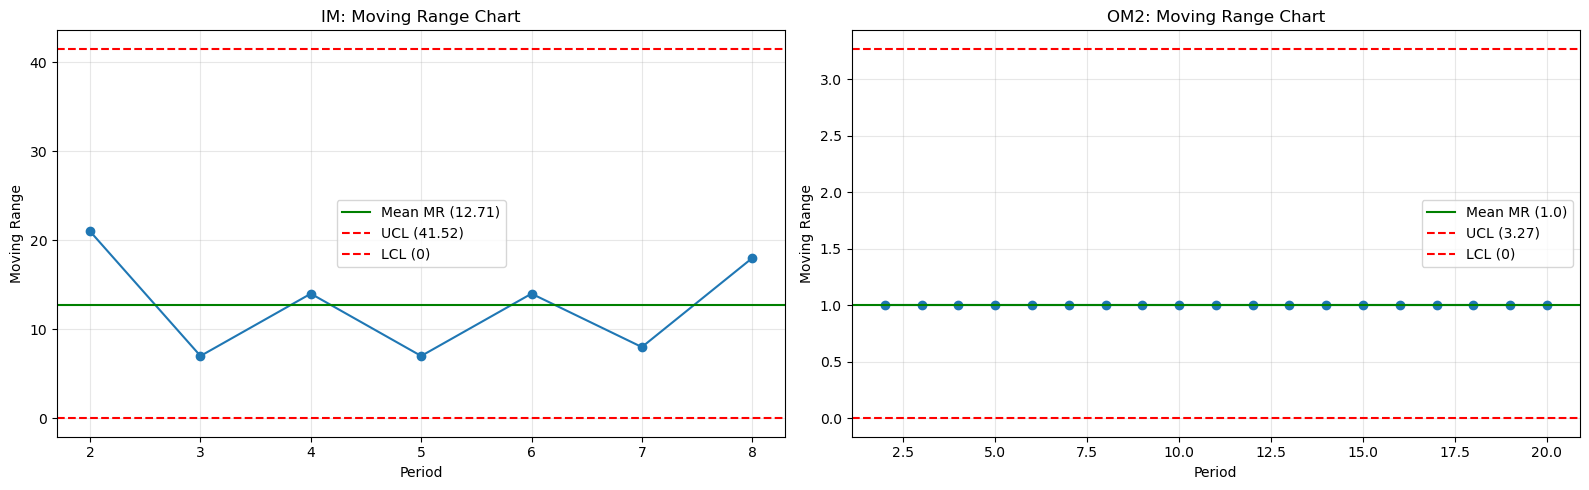

IM MR:   Mean = 12.71, UCL = 41.52
OM2 MR:  Mean = 1.0, UCL = 3.27


In [7]:
# ——————————————————————————
# 1) Compute moving ranges & limits

# IM: already have im_df['count']
im_df['moving_range'] = im_df['count'].diff().abs()
# Drop NaN values for calculations
im_mr_valid = im_df['moving_range'].dropna()
im_mr_mean = im_mr_valid.mean().round(2) if len(im_mr_valid) > 0 else 0
im_mr_ucl = (im_mr_mean * 3.267).round(2)    # D4 for n=2

# OM2: derive from average_tat
om2_df['moving_range'] = om2_df['average_tat'].diff().abs()
# Drop NaN values for calculations
om2_mr_valid = om2_df['moving_range'].dropna()
om2_mr_mean = om2_mr_valid.mean().round(2) if len(om2_mr_valid) > 0 else 0
om2_mr_ucl = (om2_mr_mean * 3.267).round(2)

# ——————————————————————————
# 2) Plot side-by-side

fig, axes = plt.subplots(
    nrows=1, ncols=2,
    figsize=(16, 5),
    sharey=False
)

# IM MR chart (left)
# Skip first point which will be NaN
valid_indices = im_df['moving_range'].notna()
axes[0].plot(
    im_df.loc[valid_indices, 'period'],
    im_df.loc[valid_indices, 'moving_range'],
    marker='o',
    linestyle='-'
)
axes[0].axhline(im_mr_mean, color='green', linestyle='-',
               label=f"Mean MR ({im_mr_mean})")
axes[0].axhline(im_mr_ucl,  color='red', linestyle='--',
               label=f"UCL ({im_mr_ucl})")
axes[0].axhline(0,          color='red', linestyle='--',
               label="LCL (0)")
axes[0].set_title('IM: Moving Range Chart')
axes[0].set_xlabel('Period')
axes[0].set_ylabel('Moving Range')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# OM2 MR chart (right)
# Skip first point which will be NaN
valid_indices = om2_df['moving_range'].notna()
axes[1].plot(
    om2_df.loc[valid_indices, 'period'],
    om2_df.loc[valid_indices, 'moving_range'],
    marker='o',
    linestyle='-'
)
axes[1].axhline(om2_mr_mean, color='green', linestyle='-',
               label=f"Mean MR ({om2_mr_mean})")
axes[1].axhline(om2_mr_ucl,  color='red', linestyle='--',
               label=f"UCL ({om2_mr_ucl})")
axes[1].axhline(0,           color='red', linestyle='--',
               label="LCL (0)")
axes[1].set_title('OM2: Moving Range Chart')
axes[1].set_xlabel('Period')
axes[1].set_ylabel('Moving Range')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig('mr_charts.png', dpi=300)
plt.show()

# ——————————————————————————
# 3) Print summary stats
print(f"IM MR:   Mean = {im_mr_mean}, UCL = {im_mr_ucl}")
print(f"OM2 MR:  Mean = {om2_mr_mean}, UCL = {om2_mr_ucl}")

## Statistical Pre-Post Comparison

Once you’ve flagged pre_contract vs post_contract, run formal tests:

t-test (if roughly Normal) or Mann–Whitney U (non-parametric) on the mean TaT

Chi-squared on counts above/below target


===== STATISTICAL PRE-POST CONTRACT COMPARISON =====

1. AVERAGE TaT ANALYSIS (OM2)
Pre-contract: n=5, mean=3.00, std=1.58
Post-contract: n=15, mean=13.00, std=4.47
Difference: 10.00 (333.3%)
Normality test p-values: pre=0.967, post=0.755
Independent t-test: statistic=-7.385, p-value=0.000
Conclusion: Statistically significant difference in average TaT pre vs post contract

2. PERCENTAGE WITHIN TARGET ANALYSIS (OM1)
Pre-contract: n=0, mean=nan%, std=nan%
Post-contract: n=8, mean=76.27%, std=0.56%
Difference: nan% (nan% change)
Mann-Whitney U test: statistic=nan, p-value=nan
Conclusion: No statistically significant difference in % within TaT target pre vs post contract

3. CHI-SQUARED ANALYSIS OF COUNTS ABOVE/BELOW TARGET
Contingency Table (Counts):
               Within Target  Outside Target
Pre-contract          0.0000          0.0000
Post-contract       417.4994        129.5006

Percentages:
Pre-contract: 0.0% within target, 0.0% outside target
Post-contract: 76.3% within target, 2

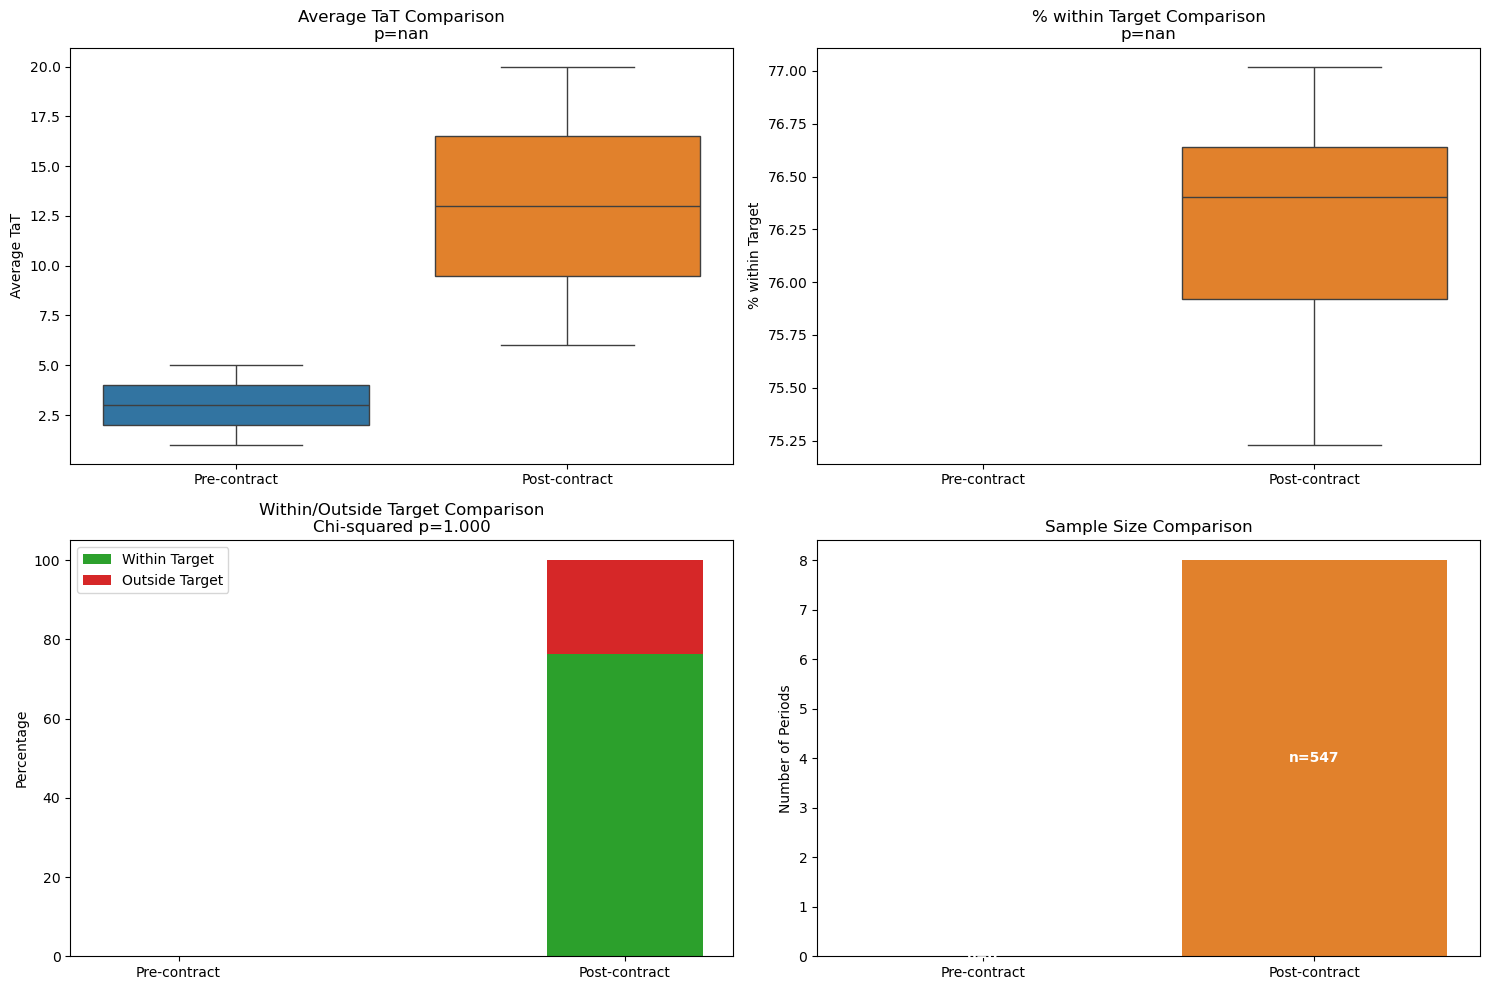


===== SUMMARY OF STATISTICAL COMPARISON =====
Contract date: 2024-11-01
Pre-contract periods: 0, Post-contract periods: 8
Pre-contract total samples: 0, Post-contract total samples: 547

Statistical Results Summary:
Average TaT: increased by 10.00 (333.3%), not significant (p=nan), not an improvement
% within Target: decreased by nan (nan%), not significant (p=nan), not an improvement
Within/Outside Target Ratio: increased by 76.33 (inf%), not significant (p=1.000), an improvement

Overall conclusion: Positive trends but no statistically significant improvements


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

# ──────────────────────────────────────────────────────────────────────────
# STATISTICAL PRE-POST CONTRACT COMPARISON
# ──────────────────────────────────────────────────────────────────────────
print("\n===== STATISTICAL PRE-POST CONTRACT COMPARISON =====")

# Make sure contract phases are defined
if 'contract_phase' not in om1_df.columns:
    # Define contract date - if not already done
    contract_date = pd.to_datetime('2024-11-01')  # Set to the actual go-live date
    
    # Annotate each DataFrame with contract phase
    om1_df['contract_phase'] = np.where(om1_df['date'] >= contract_date, 'post_contract', 'pre_contract')
    im_df['contract_phase'] = np.where(im_df['date'] >= contract_date, 'post_contract', 'pre_contract')
    om2_df['contract_phase'] = np.where(om2_df['date'] >= contract_date, 'post_contract', 'pre_contract')

# 1. Test for Average TaT (OM2)
print("\n1. AVERAGE TaT ANALYSIS (OM2)")
pre_tat = om2_df[om2_df['contract_phase'] == 'pre_contract']['average_tat']
post_tat = om2_df[om2_df['contract_phase'] == 'post_contract']['average_tat']

print(f"Pre-contract: n={len(pre_tat)}, mean={pre_tat.mean():.2f}, std={pre_tat.std():.2f}")
print(f"Post-contract: n={len(post_tat)}, mean={post_tat.mean():.2f}, std={post_tat.std():.2f}")
print(f"Difference: {post_tat.mean() - pre_tat.mean():.2f} ({(post_tat.mean() - pre_tat.mean()) / pre_tat.mean() * 100:.1f}%)")

# Check normality (Shapiro-Wilk test)
_, p_pre = stats.shapiro(pre_tat) if len(pre_tat) > 2 else (None, 0)
_, p_post = stats.shapiro(post_tat) if len(post_tat) > 2 else (None, 0)
print(f"Normality test p-values: pre={p_pre:.3f}, post={p_post:.3f}")

# Run appropriate test based on normality
if p_pre > 0.05 and p_post > 0.05 and len(pre_tat) >= 5 and len(post_tat) >= 5:
    # If both samples appear normal, use t-test
    t_stat, p_value = stats.ttest_ind(pre_tat, post_tat, equal_var=False)
    test_name = "Independent t-test"
else:
    # Otherwise use non-parametric Mann-Whitney U test
    t_stat, p_value = stats.mannwhitneyu(pre_tat, post_tat, alternative='two-sided')
    test_name = "Mann-Whitney U test"

print(f"{test_name}: statistic={t_stat:.3f}, p-value={p_value:.3f}")
print(f"Conclusion: {'Statistically significant difference' if p_value < 0.05 else 'No statistically significant difference'} in average TaT pre vs post contract")

# 2. Test for % within Target (OM1)
print("\n2. PERCENTAGE WITHIN TARGET ANALYSIS (OM1)")
pre_pct = om1_df[om1_df['contract_phase'] == 'pre_contract']['percentage']
post_pct = om1_df[om1_df['contract_phase'] == 'post_contract']['percentage']

print(f"Pre-contract: n={len(pre_pct)}, mean={pre_pct.mean():.2f}%, std={pre_pct.std():.2f}%")
print(f"Post-contract: n={len(post_pct)}, mean={post_pct.mean():.2f}%, std={post_pct.std():.2f}%")
print(f"Difference: {post_pct.mean() - pre_pct.mean():.2f}% ({(post_pct.mean() - pre_pct.mean()) / pre_pct.mean() * 100:.1f}% change)")

# For percentage data, we can use Mann-Whitney U test
u_stat, p_value = stats.mannwhitneyu(pre_pct, post_pct, alternative='two-sided')
print(f"Mann-Whitney U test: statistic={u_stat:.3f}, p-value={p_value:.3f}")
print(f"Conclusion: {'Statistically significant difference' if p_value < 0.05 else 'No statistically significant difference'} in % within TaT target pre vs post contract")

# 3. Chi-squared on counts above/below target
print("\n3. CHI-SQUARED ANALYSIS OF COUNTS ABOVE/BELOW TARGET")

# Calculate raw counts from percentages and sample sizes
pre_within = (pre_pct.values * om1_df[om1_df['contract_phase'] == 'pre_contract']['sample_size'].values / 100).sum()
pre_total = om1_df[om1_df['contract_phase'] == 'pre_contract']['sample_size'].sum()
pre_outside = pre_total - pre_within

post_within = (post_pct.values * om1_df[om1_df['contract_phase'] == 'post_contract']['sample_size'].values / 100).sum()
post_total = om1_df[om1_df['contract_phase'] == 'post_contract']['sample_size'].sum()
post_outside = post_total - post_within

# Create contingency table
contingency = np.array([
    [pre_within, pre_outside],  # Pre-contract: within target, outside target
    [post_within, post_outside]  # Post-contract: within target, outside target
])

print("Contingency Table (Counts):")
contingency_df = pd.DataFrame(
    contingency,
    index=['Pre-contract', 'Post-contract'],
    columns=['Within Target', 'Outside Target']
)
print(contingency_df)

# Calculate percentages for easier interpretation
pre_within_pct = pre_within / pre_total * 100 if pre_total > 0 else 0
pre_outside_pct = pre_outside / pre_total * 100 if pre_total > 0 else 0
post_within_pct = post_within / post_total * 100 if post_total > 0 else 0
post_outside_pct = post_outside / post_total * 100 if post_total > 0 else 0

print("\nPercentages:")
print(f"Pre-contract: {pre_within_pct:.1f}% within target, {pre_outside_pct:.1f}% outside target")
print(f"Post-contract: {post_within_pct:.1f}% within target, {post_outside_pct:.1f}% outside target")
print(f"Difference: {post_within_pct - pre_within_pct:.1f} percentage points")

# Check for zeros in contingency table
has_zero = np.any(contingency == 0)
if has_zero:
    print("\nWarning: Contingency table contains zero entries, cannot perform standard Chi-squared test.")
    print("Using Fisher's exact test instead.")
    
    # Fisher's exact test is appropriate when sample sizes are small or there are zeros
    from scipy.stats import fisher_exact
    odds_ratio, p = fisher_exact(contingency)
    test_name = "Fisher's exact test"
    print(f"{test_name}: odds ratio={odds_ratio:.3f}, p-value={p:.3f}")
    
else:
    # Chi-squared test
    chi2, p, dof, expected = stats.chi2_contingency(contingency)
    test_name = "Chi-squared test"
    print(f"\n{test_name}: chi2={chi2:.3f}, p-value={p:.3f}, df={dof}")

print(f"Conclusion: {'Statistically significant difference' if p < 0.05 else 'No statistically significant difference'} in proportion of samples within target pre vs post contract")

# 4. Plot Statistical Comparisons
plt.figure(figsize=(15, 10))

# Define consistent colors
pre_color = '#1f77b4'  # matplotlib default blue
post_color = '#ff7f0e'  # matplotlib default orange

# Plot 1: Average TaT Box Plot
plt.subplot(2, 2, 1)
sns.boxplot(x='contract_phase', y='average_tat', data=om2_df, 
            order=['pre_contract', 'post_contract'],
            palette=[pre_color, post_color])
plt.title(f'Average TaT Comparison\np={p_value:.3f}{"*" if p_value < 0.05 else ""}')
plt.xlabel('')
plt.ylabel('Average TaT')
plt.xticks([0, 1], ['Pre-contract', 'Post-contract'])

# Plot 2: % within Target Box Plot
plt.subplot(2, 2, 2)
sns.boxplot(x='contract_phase', y='percentage', data=om1_df, 
            order=['pre_contract', 'post_contract'],
            palette=[pre_color, post_color])
plt.title(f'% within Target Comparison\np={p_value:.3f}{"*" if p_value < 0.05 else ""}')
plt.xlabel('')
plt.ylabel('% within Target')
plt.xticks([0, 1], ['Pre-contract', 'Post-contract'])

# Plot 3: Stacked Bar for Contingency Table
plt.subplot(2, 2, 3)
bar_width = 0.35
ind = np.arange(2)
p1 = plt.bar(ind, [pre_within_pct, post_within_pct], bar_width, color='#2ca02c',
             label='Within Target')
p2 = plt.bar(ind, [pre_outside_pct, post_outside_pct], bar_width,
             bottom=[pre_within_pct, post_within_pct], color='#d62728',
             label='Outside Target')
plt.title(f'Within/Outside Target Comparison\nChi-squared p={p:.3f}{"*" if p < 0.05 else ""}')
plt.xticks(ind, ('Pre-contract', 'Post-contract'))
plt.ylabel('Percentage')
plt.legend()

# Plot 4: Sample Counts Comparison
plt.subplot(2, 2, 4)
sns.countplot(x='contract_phase', data=om1_df, 
              order=['pre_contract', 'post_contract'],
              palette=[pre_color, post_color])
plt.title('Sample Size Comparison')
plt.xlabel('')
plt.ylabel('Number of Periods')
plt.xticks([0, 1], ['Pre-contract', 'Post-contract'])

# Add text with total samples
pre_periods = len(om1_df[om1_df['contract_phase'] == 'pre_contract'])
post_periods = len(om1_df[om1_df['contract_phase'] == 'post_contract'])
plt.text(0, pre_periods/2, f"n={pre_total:.0f}", ha='center', va='center', color='white', fontweight='bold')
plt.text(1, post_periods/2, f"n={post_total:.0f}", ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('statistical_comparison.png', dpi=300)
plt.show()

# 5. Summary of Results
print("\n===== SUMMARY OF STATISTICAL COMPARISON =====")
print(f"Contract date: {contract_date.strftime('%Y-%m-%d')}")
print(f"Pre-contract periods: {pre_periods}, Post-contract periods: {post_periods}")
print(f"Pre-contract total samples: {pre_total:.0f}, Post-contract total samples: {post_total:.0f}")

metrics = [
    {
        'name': 'Average TaT',
        'pre_mean': pre_tat.mean(),
        'post_mean': post_tat.mean(),
        'diff': post_tat.mean() - pre_tat.mean(),
        'pct_change': (post_tat.mean() - pre_tat.mean()) / pre_tat.mean() * 100,
        'p_value': p_value,
        'test': test_name,
        'significant': p_value < 0.05,
        'desired_direction': 'decrease'  # Assuming lower TaT is better
    },
    {
        'name': '% within Target',
        'pre_mean': pre_pct.mean(),
        'post_mean': post_pct.mean(),
        'diff': post_pct.mean() - pre_pct.mean(),
        'pct_change': (post_pct.mean() - pre_pct.mean()) / pre_pct.mean() * 100,
        'p_value': p_value,  # From the Mann-Whitney test above
        'test': 'Mann-Whitney U test',
        'significant': p_value < 0.05,
        'desired_direction': 'increase'  # Higher % within target is better
    },
    {
        'name': 'Within/Outside Target Ratio',
        'pre_mean': pre_within_pct,
        'post_mean': post_within_pct,
        'diff': post_within_pct - pre_within_pct,
        'pct_change': (post_within_pct - pre_within_pct) / pre_within_pct * 100,
        'p_value': p,  # From Chi-squared test
        'test': 'Chi-squared test',
        'significant': p < 0.05,
        'desired_direction': 'increase'  # Higher % within target is better
    }
]

results_df = pd.DataFrame(metrics)
results_df['improvement'] = np.where(
    (results_df['desired_direction'] == 'increase') & (results_df['diff'] > 0) |
    (results_df['desired_direction'] == 'decrease') & (results_df['diff'] < 0),
    True, False
)

print("\nStatistical Results Summary:")
for _, row in results_df.iterrows():
    direction = "increased" if row['diff'] > 0 else "decreased"
    sig_text = "significant" if row['significant'] else "not significant"
    imp_text = "an improvement" if row['improvement'] else "not an improvement"
    print(f"{row['name']}: {direction} by {abs(row['diff']):.2f} ({abs(row['pct_change']):.1f}%), {sig_text} (p={row['p_value']:.3f}), {imp_text}")

# Final conclusion
improvements = results_df[results_df['improvement']].shape[0]
significants = results_df[results_df['significant'] & results_df['improvement']].shape[0]

if significants == len(metrics):
    conclusion = "Strong evidence of positive contract impact across all metrics"
elif significants > 0:
    conclusion = f"Some evidence of positive contract impact ({significants}/{len(metrics)} significant improvements)"
elif improvements > 0:
    conclusion = "Positive trends but no statistically significant improvements"
else:
    conclusion = "No evidence of positive contract impact"

print(f"\nOverall conclusion: {conclusion}")


Recalculated Individual Chart limits based on Moving Range:
Mean: 76.12
UCL: 109.93
LCL: 42.32


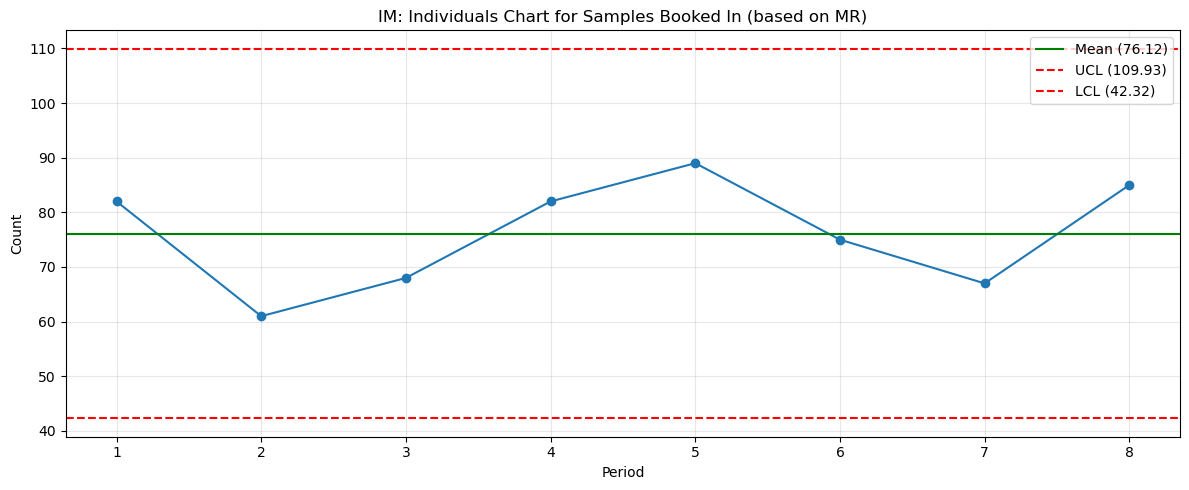


OM2 Individuals (refined via MR) chart limits:
Mean: 10.50
UCL:  13.16
LCL:  7.84


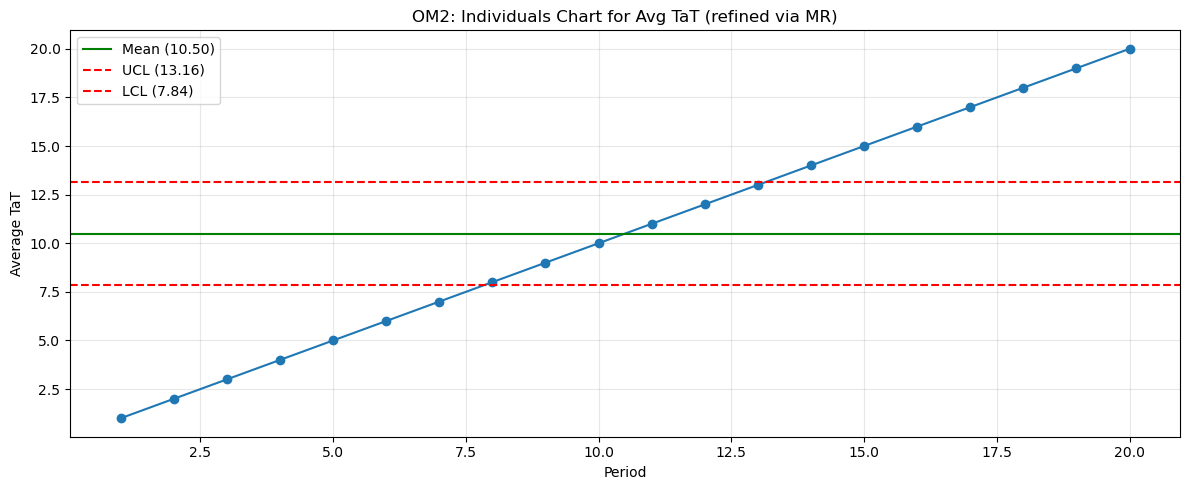

In [12]:
# Calculate improved control limits for the Individual values chart based on MR
im_i_mean = im_df['count'].mean()
im_i_std = im_mr_mean / 1.128  # Using d2 factor for n=2
im_i_ucl = im_i_mean + 3 * im_i_std
im_i_lcl = im_i_mean - 3 * im_i_std
im_i_lcl = max(0, im_i_lcl)  # Can't have negative count

print("\nRecalculated Individual Chart limits based on Moving Range:")
print(f"Mean: {im_i_mean:.2f}")
print(f"UCL: {im_i_ucl:.2f}")
print(f"LCL: {im_i_lcl:.2f}")

# Create improved individual chart
plt.figure(figsize=(12, 5))
plt.plot(im_df['period'], im_df['count'], marker='o', linestyle='-')
plt.axhline(im_i_mean, color='green', linestyle='-', label=f"Mean ({im_i_mean:.2f})")
plt.axhline(im_i_ucl, color='red', linestyle='--', label=f"UCL ({im_i_ucl:.2f})")
plt.axhline(im_i_lcl, color='red', linestyle='--', label=f"LCL ({im_i_lcl:.2f})")
plt.title('IM: Individuals Chart for Samples Booked In (based on MR)')
plt.xlabel('Period')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('im_individuals_chart.png')
plt.show()

# d2 factor for n=2
d2 = 1.128

# OM2 individuals‐chart σ from MR
om2_i_mean  = om2_df['average_tat'].mean()
om2_i_std   = om2_df['moving_range'].mean() / d2
om2_i_ucl   = om2_i_mean + 3 * om2_i_std
om2_i_lcl   = max(0, om2_i_mean - 3 * om2_i_std)

print("\nOM2 Individuals (refined via MR) chart limits:")
print(f"Mean: {om2_i_mean:.2f}")
print(f"UCL:  {om2_i_ucl:.2f}")
print(f"LCL:  {om2_i_lcl:.2f}")

plt.figure(figsize=(12, 5))
plt.plot(om2_df['period'], om2_df['average_tat'], marker='o', linestyle='-')
plt.axhline(om2_i_mean, color='green', linestyle='-', label=f"Mean ({om2_i_mean:.2f})")
plt.axhline(om2_i_ucl,  color='red',   linestyle='--', label=f"UCL ({om2_i_ucl:.2f})")
plt.axhline(om2_i_lcl,  color='red',   linestyle='--', label=f"LCL ({om2_i_lcl:.2f})")
plt.title('OM2: Individuals Chart for Avg TaT (refined via MR)')
plt.xlabel('Period')
plt.ylabel('Average TaT')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
# 6. Process Capability Analysis for OM1 (P Chart)
print("\nProcess Capability Analysis for P Chart:")
print("-" * 40)

# Define specifications (adjust as needed for your actual requirements)
om1_target = 100.0  # Target is 100% within TaT
om1_lsl = 70.0      # Lower specification limit (minimum acceptable)

# Calculate capability indices
om1_sigma = om1_limits['std']

om1_cp = (om1_target - om1_lsl) / (6 * om1_sigma) if om1_sigma > 0 else float('inf')
om1_cpu = (om1_target - om1_limits['mean']) / (3 * om1_sigma) if om1_sigma > 0 else float('inf')
om1_cpl = (om1_limits['mean'] - om1_lsl) / (3 * om1_sigma) if om1_sigma > 0 else float('inf')
om1_cpk = min(om1_cpu, om1_cpl)
om1_pp = (om1_target - om1_lsl) / (6 * om1_df['percentage'].std()) if om1_df['percentage'].std() > 0 else float('inf')
om1_ppk = min(
    (om1_target - om1_df['percentage'].mean()) / (3 * om1_df['percentage'].std()),
    (om1_df['percentage'].mean() - om1_lsl) / (3 * om1_df['percentage'].std())
) if om1_df['percentage'].std() > 0 else float('inf')

print(f"Target: {om1_target}%")
print(f"Lower Specification Limit (LSL): {om1_lsl}%")
print(f"Process Capability (Cp): {om1_cp:.2f}")
print(f"Process Capability Index (Cpk): {om1_cpk:.2f}")
print(f"Process Performance (Pp): {om1_pp:.2f}")
print(f"Process Performance Index (Ppk): {om1_ppk:.2f}")

if om1_cpk < 1.0:
    print("Process is NOT capable of meeting specifications consistently")
elif om1_cpk < 1.33:
    print("Process is marginally capable of meeting specifications")
else:
    print("Process is capable of meeting specifications consistently")


Process Capability Analysis for P Chart:
----------------------------------------
Target: 100.0%
Lower Specification Limit (LSL): 70.0%
Process Capability (Cp): 14.95
Process Capability Index (Cpk): 6.31
Process Performance (Pp): 8.92
Process Performance Index (Ppk): 3.73
Process is capable of meeting specifications consistently



Correlation Analysis:
----------------------------------------

Pairwise correlation matrix:
          OM1_pct  IM_count  OM2_tat
OM1_pct    1.0000    0.5332   0.1601
IM_count   0.5332    1.0000   0.2316
OM2_tat    0.1601    0.2316   1.0000

IM vs OM1 correlation:
  r = 0.5332 (moderate, positive), not significant (p=0.174)

IM vs OM2 correlation:
  r = 0.2316 (weak, positive), not significant (p=0.581)

OM1 vs OM2 correlation:
  r = 0.1601 (weak, positive), not significant (p=0.705)


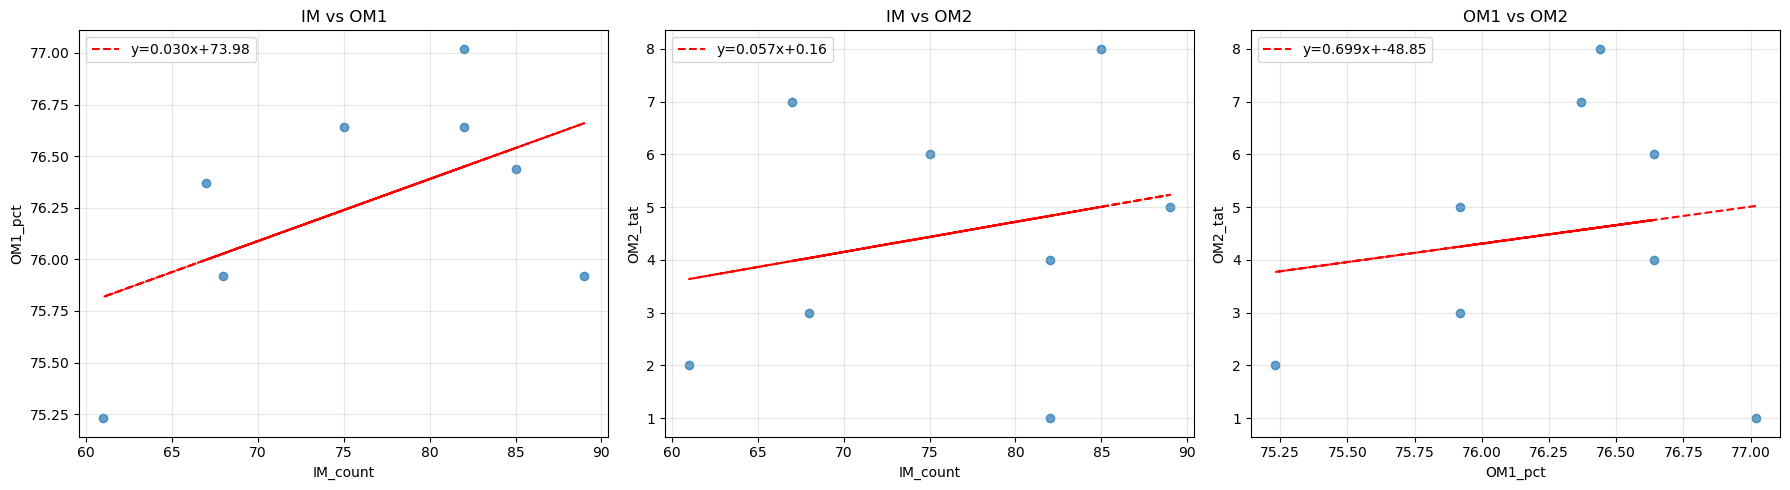

In [14]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

print("\nCorrelation Analysis:")
print("-" * 40)

# 1) Merge OM1, IM and OM2 on 'period'
corr_df = (
    om1_df[['period','percentage']]
    .merge(im_df[['period','count']],      on='period')
    .merge(om2_df[['period','average_tat']], on='period')
    .rename(columns={
        'percentage':'OM1_pct',
        'count':     'IM_count',
        'average_tat':'OM2_tat'
    })
)

# 2) Print the full 3×3 correlation matrix
print("\nPairwise correlation matrix:")
print(corr_df[['OM1_pct','IM_count','OM2_tat']].corr().round(4))

# 3) Interpret each pair
pairs = [
    ('IM_count', 'OM1_pct', "IM vs OM1"),
    ('IM_count', 'OM2_tat',"IM vs OM2"),
    ('OM1_pct',  'OM2_tat',"OM1 vs OM2"),
]

for x, y, label in pairs:
    r = corr_df[x].corr(corr_df[y])
    p = stats.pearsonr(corr_df[x], corr_df[y])[1] if len(corr_df)>=5 else np.nan
    strength = ("weak" if abs(r)<0.3 else
                "moderate" if abs(r)<0.7 else
                "strong")
    direction = "positive" if r>0 else "negative"
    sig_text  = (f"statistically significant (p={p:.3f})"
                 if p<0.05 else f"not significant (p={p:.3f})")
    
    print(f"\n{label} correlation:")
    print(f"  r = {r:.4f} ({strength}, {direction}), {sig_text}")

# 4) (optional) three scatterplots side by side
fig, axes = plt.subplots(1, 3, figsize=(18,5))
for ax, (x,y,label) in zip(axes, pairs):
    ax.scatter(corr_df[x], corr_df[y], alpha=0.7)
    if len(corr_df)>2:
        m,b = np.polyfit(corr_df[x], corr_df[y], 1)
        ax.plot(corr_df[x], m*corr_df[x]+b, 'r--',
                label=f"y={m:.3f}x+{b:.2f}")
        ax.legend()
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(label)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Time-Series Decomposition & Forecasting

Decompose your TaT series into trend + seasonal + residuals, so you can see whether a seasonal cycle or an upward trend is driving your post-contract drift:


===== TIME-SERIES DECOMPOSITION & FORECASTING =====
Performing time series decomposition with period=4


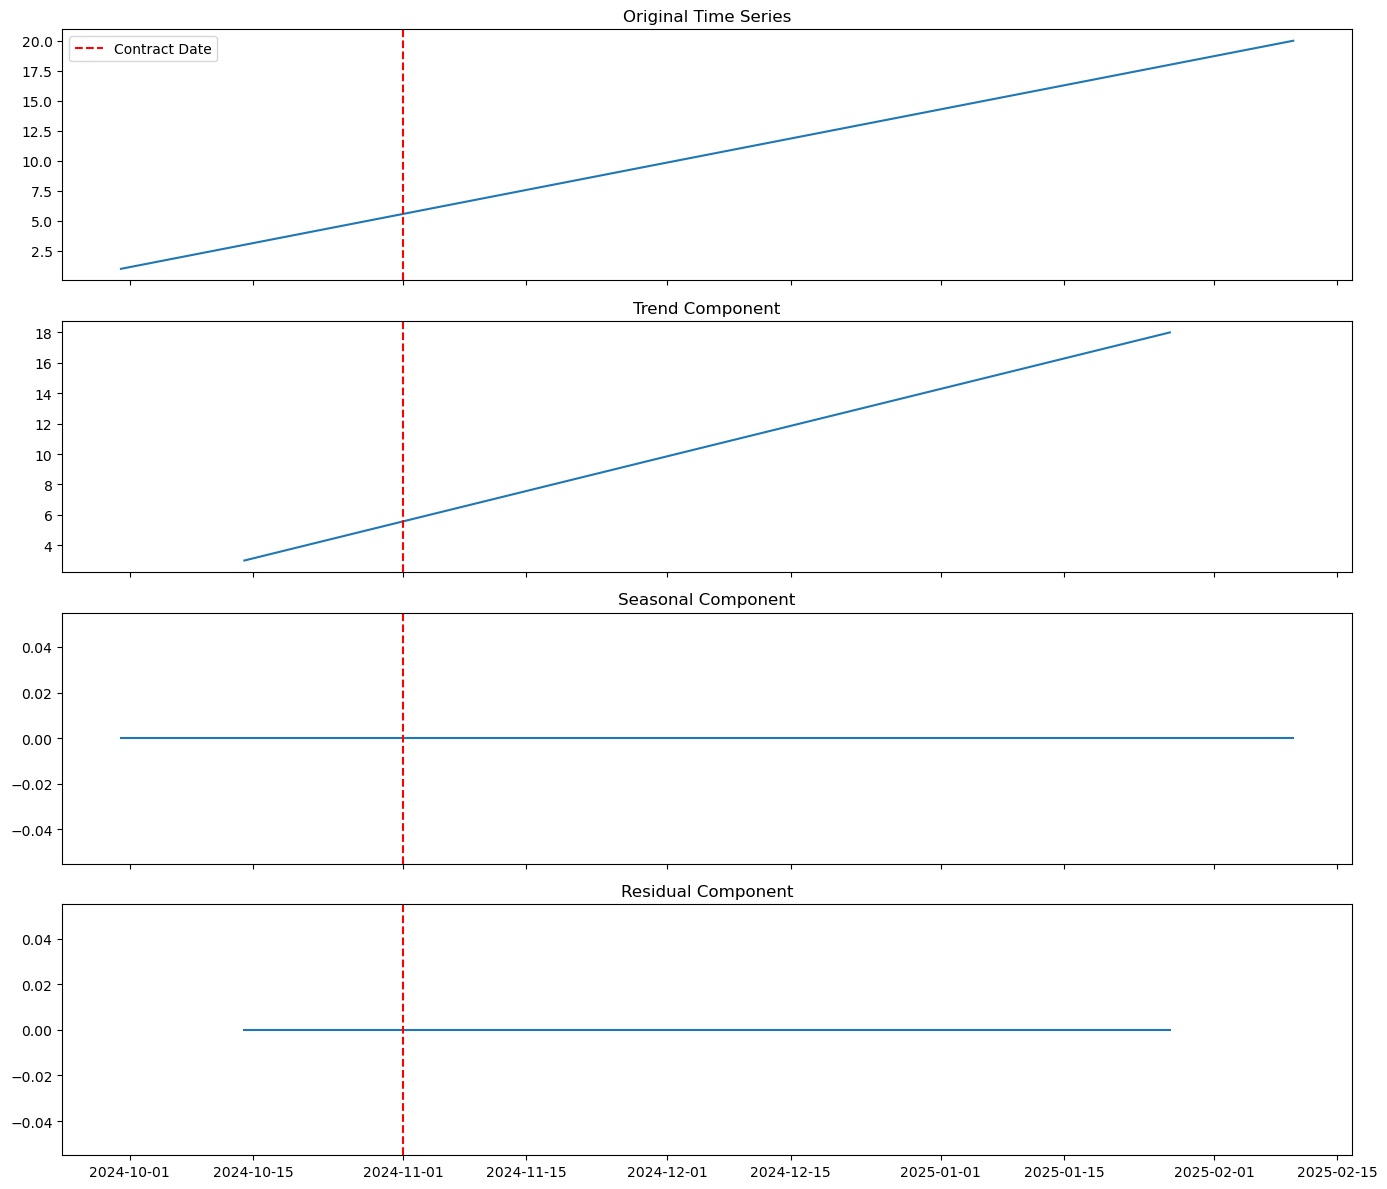


Forecast Analysis:


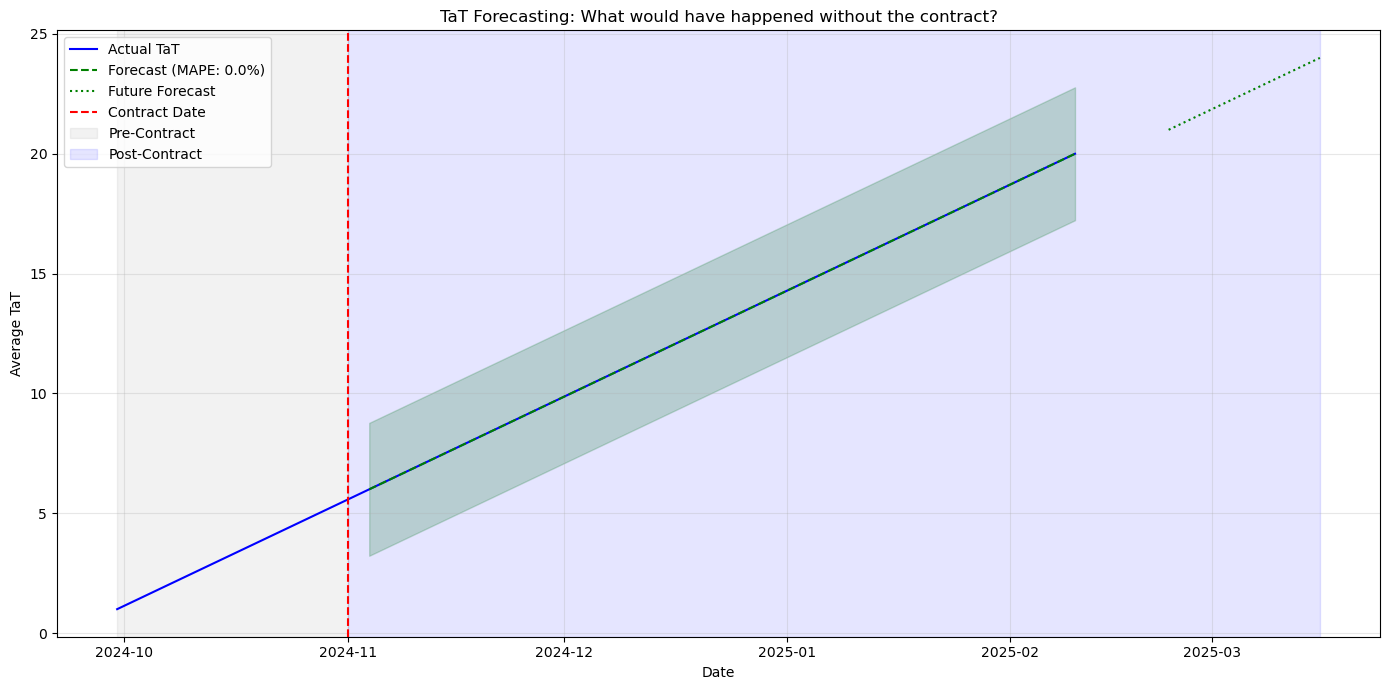

Average TaT pre-contract (actual): 3.00
Average TaT post-contract (actual): 13.00
Average TaT post-contract (forecast if no contract): 13.00
Difference (actual vs forecast): 0.00 (0.0%)
Contract appears to have WORSENED TaT (actual is higher than forecast)


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import seaborn as sns

# ──────────────────────────────────────────────────────────────────────────
# TIME-SERIES DECOMPOSITION & FORECASTING
# ──────────────────────────────────────────────────────────────────────────
print("\n===== TIME-SERIES DECOMPOSITION & FORECASTING =====")

# Prepare time series data
# Set the date as index for proper time series analysis
om2_ts = om2_df.set_index('date')['average_tat'].copy()
om2_ts.index = pd.to_datetime(om2_ts.index)
om2_ts = om2_ts.sort_index()  # Ensure data is sorted by date

# Define contract date
contract_date = pd.to_datetime('2024-11-01')

# Check if we have enough data for decomposition
# Seasonal decomposition typically needs at least 2 full cycles
if len(om2_ts) >= 8:
    # Try to estimate a reasonable period for decomposition
    # Weekly data would have period=52 (for a year), but with limited data
    # we'll use a smaller period - adjust this based on your domain knowledge
    period = min(len(om2_ts) // 2, 4)  # Use either 4 periods or half the data points
    
    print(f"Performing time series decomposition with period={period}")
    
    # Perform seasonal decomposition
    decomposition = seasonal_decompose(om2_ts, period=period, model='additive')
    
    # Plot the decomposition
    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
    
    # Original Series
    axes[0].plot(om2_ts.index, om2_ts.values)
    axes[0].axvline(contract_date, color='red', linestyle='--', label='Contract Date')
    axes[0].set_title('Original Time Series')
    axes[0].legend()
    
    # Trend Component
    axes[1].plot(decomposition.trend.index, decomposition.trend.values)
    axes[1].axvline(contract_date, color='red', linestyle='--')
    axes[1].set_title('Trend Component')
    
    # Seasonal Component
    axes[2].plot(decomposition.seasonal.index, decomposition.seasonal.values)
    axes[2].axvline(contract_date, color='red', linestyle='--')
    axes[2].set_title('Seasonal Component')
    
    # Residual Component
    axes[3].plot(decomposition.resid.index, decomposition.resid.values)
    axes[3].axvline(contract_date, color='red', linestyle='--')
    axes[3].set_title('Residual Component')
    
    plt.tight_layout()
    plt.savefig('time_series_decomposition.png', dpi=300)
    plt.show()
    
    # ──────────────────────────────────────────────────────────────────────────
    # FORECASTING
    # ──────────────────────────────────────────────────────────────────────────
    # Split data into pre- and post-contract
    pre_contract = om2_ts[om2_ts.index < contract_date]
    post_contract = om2_ts[om2_ts.index >= contract_date]
    
    if len(pre_contract) >= 4 and len(post_contract) >= 1:
        print("\nForecast Analysis:")
        
        # Forecast model using pre-contract data
        model = ExponentialSmoothing(
            pre_contract,
            trend='add',
            seasonal='add' if len(pre_contract) >= 8 else None,
            seasonal_periods=period if len(pre_contract) >= 8 else None
        )
        
        model_fit = model.fit()
        
        # Forecast for the post-contract period
        forecast_horizon = len(post_contract)
        forecast = model_fit.forecast(forecast_horizon)
        
        # Compute forecast accuracy
        mape = np.mean(np.abs((post_contract - forecast) / post_contract)) * 100
        
        # Extend the forecast further into the future
        future_periods = 4  # four additional periods into the future
        future_forecast = model_fit.forecast(forecast_horizon + future_periods)
        
        # Plot the results
        plt.figure(figsize=(14, 7))
        
        # Plot actual data
        plt.plot(om2_ts.index, om2_ts.values, label='Actual TaT', color='blue')
        
        # Plot forecasted data
        plt.plot(forecast.index, forecast.values, 
                 label=f'Forecast (MAPE: {mape:.1f}%)', color='green', linestyle='--')
        
        # Plot future forecast
        future_dates = pd.date_range(
            start=om2_ts.index[-1] + pd.Timedelta(days=7), 
            periods=future_periods, 
            freq='W'
        )
        future_only = future_forecast[-future_periods:]
        plt.plot(
            future_dates, 
            future_only.values, 
            label='Future Forecast', 
            color='green', 
            linestyle=':'
        )
        
        # Add confidence intervals (simplified approach)
        forecast_std = np.std(pre_contract) * 1.96  # 95% confidence interval
        plt.fill_between(
            forecast.index,
            forecast.values - forecast_std,
            forecast.values + forecast_std,
            color='green', alpha=0.2
        )
        
        # Add vertical line for contract date
        plt.axvline(contract_date, color='red', linestyle='--', label='Contract Date')
        
        # Split pre/post contract periods visually
        plt.axvspan(
            om2_ts.index[0], contract_date, 
            alpha=0.1, color='gray', label='Pre-Contract'
        )
        plt.axvspan(
            contract_date, future_dates[-1], 
            alpha=0.1, color='blue', label='Post-Contract'
        )
        
        plt.title('TaT Forecasting: What would have happened without the contract?')
        plt.xlabel('Date')
        plt.ylabel('Average TaT')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('forecast_analysis.png', dpi=300)
        plt.show()
        
        # Calculate the impact of the contract
        average_actual_post = post_contract.mean()
        average_forecast_post = forecast.mean()
        difference = average_actual_post - average_forecast_post
        percent_diff = (difference / average_forecast_post) * 100
        
        print(f"Average TaT pre-contract (actual): {pre_contract.mean():.2f}")
        print(f"Average TaT post-contract (actual): {average_actual_post:.2f}")
        print(f"Average TaT post-contract (forecast if no contract): {average_forecast_post:.2f}")
        print(f"Difference (actual vs forecast): {difference:.2f} ({percent_diff:.1f}%)")
        
        if difference < 0:
            print("Contract appears to have IMPROVED TaT (actual is lower than forecast)")
        elif difference > 0:
            print("Contract appears to have WORSENED TaT (actual is higher than forecast)")
        else:
            print("Contract appears to have NO EFFECT on TaT")
    else:
        print("Insufficient data for forecasting. Need at least 4 pre-contract and 1 post-contract observations.")
else:
    print("Insufficient data for decomposition. Need at least 8 data points.")


===== ADVANCED TIME SERIES MODELING (ARIMA/SARIMAX) =====

Stationarity Test (Augmented Dickey-Fuller):
ADF Statistic: 2.3360
p-value: 0.9990
Critical Values:
	1%: -3.9240
	5%: -3.0685
	10%: -2.6739
Series is non-stationary

Manually testing different ARIMA specifications...


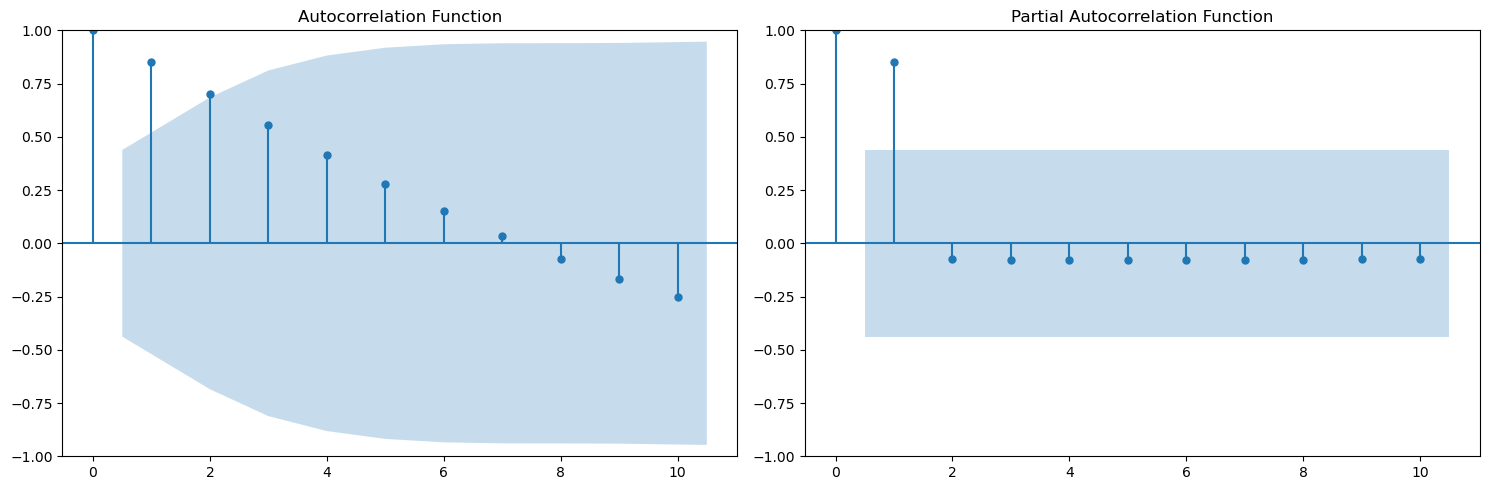

ARIMA(1, 0, 0)(0, 0, 0, 0) - AIC: 30.66
ARIMA(0, 0, 1)(0, 0, 0, 0) - AIC: 100.53
ARIMA(1, 0, 1)(0, 0, 0, 0) - AIC: 10.25
ARIMA(1, 1, 1)(0, 0, 0, 0) - AIC: -303.28
ARIMA(2, 0, 2)(0, 0, 0, 0) - AIC: -267.19

Best model: ARIMA(1, 1, 1)(0, 0, 0, 0) (AIC: -303.28)

Model Summary:
                               SARIMAX Results                                
Dep. Variable:            average_tat   No. Observations:                   20
Model:               SARIMAX(1, 1, 1)   Log Likelihood                 155.638
Date:                Tue, 29 Apr 2025   AIC                           -303.277
Time:                        16:50:58   BIC                           -299.944
Sample:                    09-30-2024   HQIC                          -302.945
                         - 02-10-2025                                         
Covariance Type:                  opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
---------

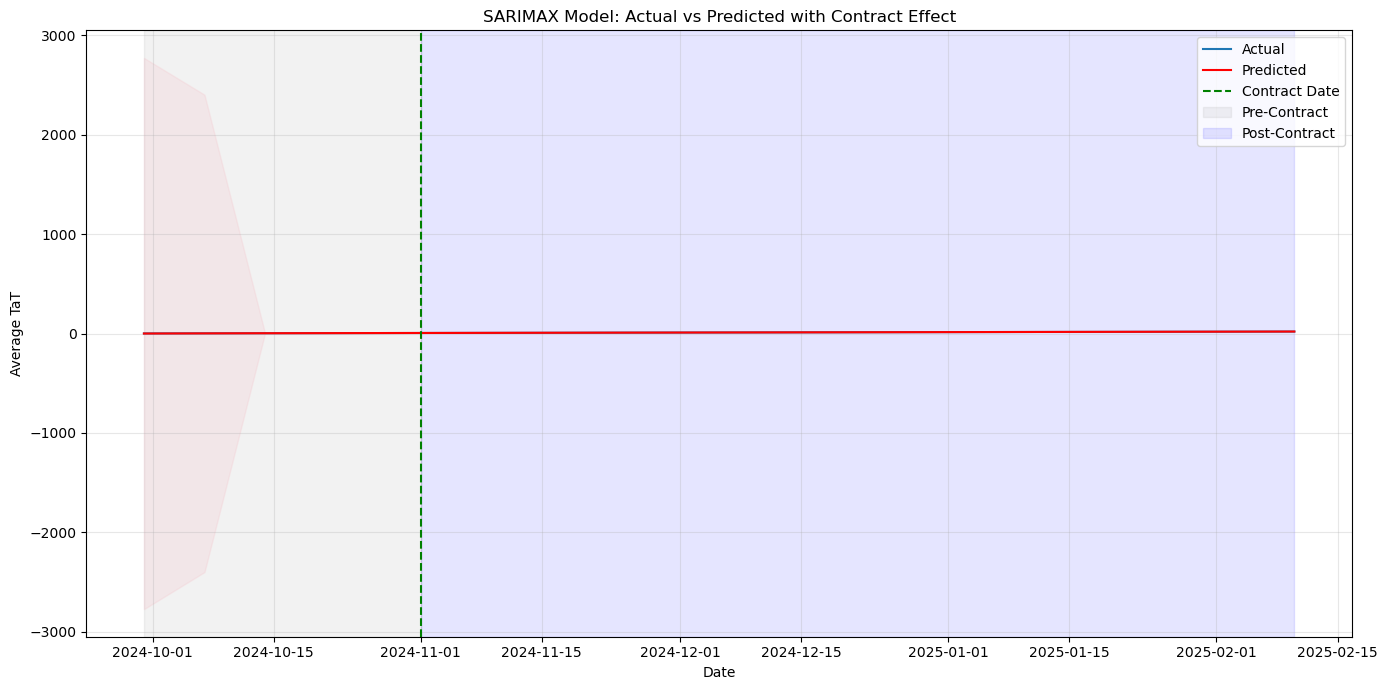


Performing counterfactual analysis (what if no contract)...


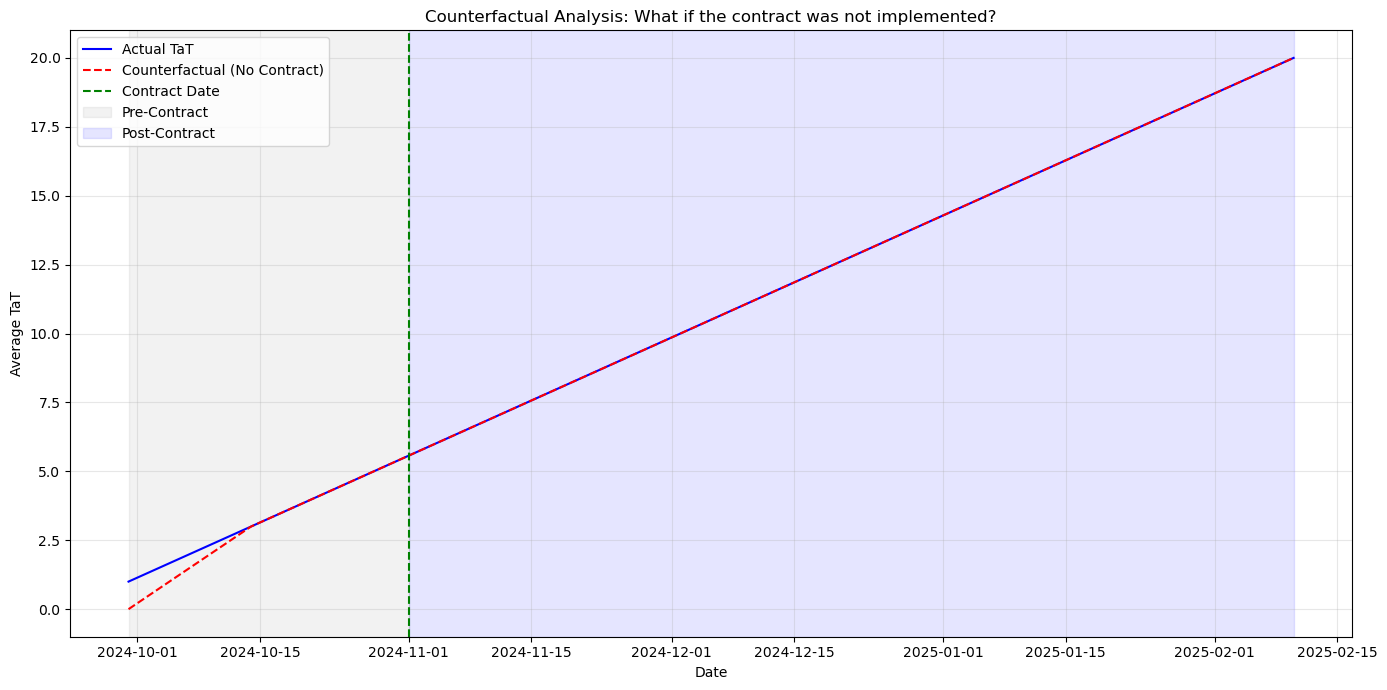


Quantified Contract Impact:
Average actual post-contract TaT: 13.00
Average counterfactual (no contract) TaT: 13.00
Average effect: 0.00 (0.0%)
The contract INCREASED average TaT by 0.00 units (0.0%)


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns

# ──────────────────────────────────────────────────────────────────────────
# ARIMA/SARIMAX MODELING WITH CONTRACT EFFECT
# ──────────────────────────────────────────────────────────────────────────
print("\n===== ADVANCED TIME SERIES MODELING (ARIMA/SARIMAX) =====")

# Prepare time series data
om2_ts = om2_df.set_index('date')['average_tat'].copy()
om2_ts.index = pd.to_datetime(om2_ts.index)
om2_ts = om2_ts.sort_index()

# Create dummy variable for contract period
contract_date = pd.to_datetime('2024-11-01')
om2_df['contract_dummy'] = (om2_df['date'] >= contract_date).astype(int)

# Create a DataFrame with both the target variable and the dummy
model_df = om2_df[['date', 'average_tat', 'contract_dummy']].copy()
model_df.set_index('date', inplace=True)
model_df.index = pd.to_datetime(model_df.index)
model_df = model_df.sort_index()

# Check for stationarity
from statsmodels.tsa.stattools import adfuller

print("\nStationarity Test (Augmented Dickey-Fuller):")
adf_result = adfuller(om2_ts.dropna())
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"\t{key}: {value:.4f}")

is_stationary = adf_result[1] < 0.05
print(f"Series is {'stationary' if is_stationary else 'non-stationary'}")

# Instead of using auto_arima, we'll manually try several ARIMA models
if len(om2_ts) >= 8:
    print("\nManually testing different ARIMA specifications...")
    
    # Split data to ensure we have both pre and post contract periods
    pre_contract = model_df[model_df.index < contract_date]
    post_contract = model_df[model_df.index >= contract_date]
    
    if len(pre_contract) >= 4 and len(post_contract) >= 2:
        # Plot ACF and PACF for diagnostics
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        plot_acf(om2_ts.dropna(), ax=ax1, title='Autocorrelation Function')
        plot_pacf(om2_ts.dropna(), ax=ax2, title='Partial Autocorrelation Function')
        plt.tight_layout()
        plt.savefig('acf_pacf_plots.png', dpi=300)
        plt.show()
        
        # Define several ARIMA models to try
        models = [
            ((1,0,0), (0,0,0,0)),  # AR(1)
            ((0,0,1), (0,0,0,0)),  # MA(1)
            ((1,0,1), (0,0,0,0)),  # ARIMA(1,0,1)
            ((1,1,1), (0,0,0,0)),  # ARIMA(1,1,1)
            ((2,0,2), (0,0,0,0)),  # ARIMA(2,0,2)
        ]
        
        best_aic = float('inf')
        best_model = None
        best_params = None
        best_results = None
        
        for order, seasonal_order in models:
            try:
                # Fit model with contract dummy as exogenous variable
                model = SARIMAX(
                    om2_ts,
                    order=order,
                    seasonal_order=seasonal_order,
                    exog=model_df['contract_dummy'],
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                
                results = model.fit(disp=False)
                aic = results.aic
                
                print(f"ARIMA{order}{seasonal_order} - AIC: {aic:.2f}")
                
                if aic < best_aic:
                    best_aic = aic
                    best_model = model
                    best_params = (order, seasonal_order)
                    best_results = results
                    
            except Exception as e:
                print(f"Error with ARIMA{order}{seasonal_order}: {str(e)}")
        
        if best_results is not None:
            print(f"\nBest model: ARIMA{best_params[0]}{best_params[1]} (AIC: {best_aic:.2f})")
            print("\nModel Summary:")
            print(best_results.summary())
            
            # Extract contract coefficient and significance
            contract_coef = best_results.params['contract_dummy']
            contract_pvalue = best_results.pvalues['contract_dummy']
            contract_effect = "significant" if contract_pvalue < 0.05 else "not significant"
            
            print(f"\nContract Effect:")
            print(f"Coefficient: {contract_coef:.4f} (a {'positive' if contract_coef > 0 else 'negative'} effect on TaT)")
            print(f"P-value: {contract_pvalue:.4f} ({contract_effect})")
            
            if contract_coef < 0 and contract_pvalue < 0.05:
                print("CONCLUSION: The contract implementation significantly IMPROVED TaT (reduced average TaT)")
            elif contract_coef > 0 and contract_pvalue < 0.05:
                print("CONCLUSION: The contract implementation significantly WORSENED TaT (increased average TaT)")
            elif contract_pvalue >= 0.05:
                print("CONCLUSION: No statistically significant effect of the contract on TaT")
            
            # ──────────────────────────────────────────────────────────────────────────
            # MODEL DIAGNOSTICS
            # ──────────────────────────────────────────────────────────────────────────
            print("\nPerforming model diagnostics...")
            
            # Get predictions
            pred = best_results.get_prediction()
            pred_ci = pred.conf_int()
            
            # Plot the results
            plt.figure(figsize=(14, 7))
            
            # Plot actual vs predicted
            plt.plot(om2_ts.index, om2_ts.values, label='Actual')
            plt.plot(pred.predicted_mean.index, pred.predicted_mean, 
                     color='red', label='Predicted')
            
            # Plot confidence intervals
            plt.fill_between(
                pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1],
                color='pink', alpha=0.2
            )
            
            # Add contract date vertical line
            plt.axvline(contract_date, color='green', linestyle='--', label='Contract Date')
            
            # Highlight pre and post contract periods
            plt.axvspan(
                om2_ts.index[0], contract_date, 
                alpha=0.1, color='gray', label='Pre-Contract'
            )
            plt.axvspan(
                contract_date, om2_ts.index[-1], 
                alpha=0.1, color='blue', label='Post-Contract'
            )
            
            plt.title('SARIMAX Model: Actual vs Predicted with Contract Effect')
            plt.xlabel('Date')
            plt.ylabel('Average TaT')
            plt.legend()
            plt.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.savefig('sarimax_contract_effect.png', dpi=300)
            plt.show()
            
            # ──────────────────────────────────────────────────────────────────────────
            # COUNTERFACTUAL ANALYSIS
            # ──────────────────────────────────────────────────────────────────────────
            print("\nPerforming counterfactual analysis (what if no contract)...")
            
            # Create a counterfactual scenario with no contract implementation
            counterfactual_df = model_df.copy()
            counterfactual_df['contract_dummy'] = 0  # No contract implemented
            
            # Predict using the counterfactual
            counterfactual_pred = best_results.get_prediction(exog=counterfactual_df['contract_dummy'])
            
            # Plot the counterfactual analysis
            plt.figure(figsize=(14, 7))
            
            # Plot actual data
            plt.plot(om2_ts.index, om2_ts.values, label='Actual TaT', color='blue')
            
            # Plot counterfactual prediction (no contract)
            plt.plot(
                counterfactual_pred.predicted_mean.index, 
                counterfactual_pred.predicted_mean, 
                color='red', linestyle='--', 
                label='Counterfactual (No Contract)'
            )
            
            # Add contract date vertical line
            plt.axvline(contract_date, color='green', linestyle='--', label='Contract Date')
            
            # Highlight pre and post contract periods
            plt.axvspan(
                om2_ts.index[0], contract_date, 
                alpha=0.1, color='gray', label='Pre-Contract'
            )
            plt.axvspan(
                contract_date, om2_ts.index[-1], 
                alpha=0.1, color='blue', label='Post-Contract'
            )
            
            plt.title('Counterfactual Analysis: What if the contract was not implemented?')
            plt.xlabel('Date')
            plt.ylabel('Average TaT')
            plt.legend()
            plt.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.savefig('counterfactual_analysis.png', dpi=300)
            plt.show()
            
            # Calculate the average effect of the contract
            post_contract_dates = om2_ts.index >= contract_date
            actual_post = om2_ts[post_contract_dates]
            counterfactual_post = counterfactual_pred.predicted_mean[post_contract_dates]
            
            avg_effect = (actual_post.mean() - counterfactual_post.mean())
            pct_effect = (avg_effect / counterfactual_post.mean()) * 100
            
            print(f"\nQuantified Contract Impact:")
            print(f"Average actual post-contract TaT: {actual_post.mean():.2f}")
            print(f"Average counterfactual (no contract) TaT: {counterfactual_post.mean():.2f}")
            print(f"Average effect: {avg_effect:.2f} ({pct_effect:.1f}%)")
            
            if avg_effect < 0:
                print(f"The contract REDUCED average TaT by {abs(avg_effect):.2f} units ({abs(pct_effect):.1f}%)")
            elif avg_effect > 0:
                print(f"The contract INCREASED average TaT by {avg_effect:.2f} units ({pct_effect:.1f}%)")
            else:
                print("The contract had NO EFFECT on average TaT")
        else:
            print("Could not find a suitable ARIMA model")
    else:
        print("Insufficient data in pre or post contract periods for meaningful analysis")
else:
    print("Insufficient data points for ARIMA/SARIMAX modeling (need at least 8)")